# Getting Started with the Simple API

The `metaheuristic_designer.simple` module provides ready‑to‑use wrappers for
common metaheuristics.  You just pass your objective function, a few
hyperparameters, and a random seed – the wrapper builds the whole strategy
and returns an `Algorithm` instance.

In [1]:
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Sphere
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reproducibility
rng = mhd.check_random_state(42)

## 1. Objective function (Sphere in 5D, minimisation)

In [2]:
DIM = 5
objfunc = Sphere(DIM, mode="min")

## 2. Run a Genetic Algorithm

The GA wrapper chooses sensible defaults: tournament selection, Gaussian
mutation, uniform crossover, elitism, etc.  You only need to set the
population size and maybe the number of generations.

In [3]:
ga_algo = mhd.simple.genetic_algorithm_real(
    objfunc,
    population_size=100,
    mutation_strength=0.1,
    mutated_components=1,
    stop_cond="ngen",
    ngen=1000,
    reporter="tqdm",
    random_state=rng,
)
ga_population = ga_algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 3. Run a Differential Evolution algorithm

DE works directly on real vectors.  The wrapper selects the `DE/rand/1`
variant by default.

In [4]:
de_algo = mhd.simple.differential_evolution_real(
    objfunc,
    population_size=100,
    de_operator_name="DE/current-to-rand/1",
    F=0.8,
    Cr=0.9,
    stop_cond="ngen",
    ngen=1000,
    reporter="verbose",
    random_state=rng,
)
de_algo.reporter.verbose_timer = -1
de_population = de_algo.optimize()

Initializing optimization of "Sphere function" using "DE"
---------------------------------------------------------

Optimizing "Sphere function" using "DE":
	Progress:                 0%
	Real time Spent:          0.0000s
	CPU time Spent:           0.0000s
	Generation:               0
	Best fitness:             4435.75
	Evaluations of fitness:   0
	Iterations stuck:         0


Optimizing "Sphere function" using "DE":
	Progress:                 0%
	Real time Spent:          0.0028s
	CPU time Spent:           0.0033s
	Generation:               1
	Best fitness:             3811.78
	Evaluations of fitness:   200
	Iterations stuck:         0


Optimizing "Sphere function" using "DE":
	Progress:                 0%
	Real time Spent:          0.0038s
	CPU time Spent:           0.0042s
	Generation:               2
	Best fitness:             1324.73
	Evaluations of fitness:   300
	Iterations stuck:         0


Optimizing "Sphere function" using "DE":
	Progress:                 0%
	Real time Sp

## 4. Run a Particle Swarm Optimisation (PSO)

PSO uses a swarm of particles with velocity updates.  The simple wrapper
handles the required `PSOEncoding`, `ExtendedInitializer` and
`ExtendedConstraintHandler` internally.

In [5]:
# pso_algo = mhd.simple.particle_swarm_real(
#     objfunc,
#     population_size=50,
#     w=0.7,
#     c1=1.5,
#     c2=1.5,
#     stop_cond="ngen",
#     ngen=1000,
#     reporter="tqdm",
#     random_state=rng,
# )
# pso_population = pso_algo.optimize()
pso_algo = mhd.simple.local_search_real(
    objfunc,
    mutated_components=1,
    mutation_strength=1,
    stop_cond="ngen",
    ngen=1000,
    reporter="tqdm",
    random_state=rng,
)
pso_population = pso_algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 5. Compare the results

In [6]:
_, ga_best = ga_population.best_solution(problem_space=True)
_, de_best = de_population.best_solution(problem_space=True)
_, pso_best = pso_population.best_solution(problem_space=True)

print(f"GA best objective:  {ga_best:.6f}")
print(f"DE best objective:  {de_best:.6f}")
print(f"PSO best objective: {pso_best:.6f}")

GA best objective:  0.000000
DE best objective:  408.161116
PSO best objective: 0.000000


## 6. Three‑way convergence plot

We extract the history of each algorithm and plot the best objective over
generations on the same axes.

,iteration,best_objective,algorithm
0,0,1.660306e+04,GA
1,1,1.012768e+04,GA
2,2,5.836896e+03,GA
3,3,2.130159e+03,GA
4,4,1.228675e+03,GA
...,...,...,...
2995,995,1.007822e-08,PSO
2996,996,1.007822e-08,PSO
2997,997,1.007822e-08,PSO
2998,998,1.007822e-08,PSO


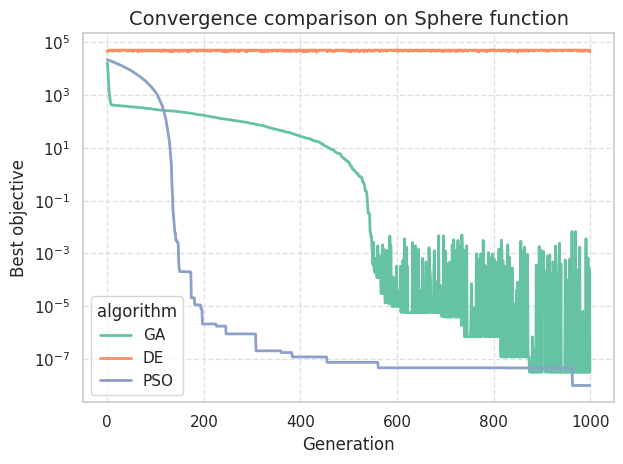

In [7]:
# Retrieve dataframes
ga_df = ga_algo.history_tracker.to_pandas()
de_df = de_algo.history_tracker.to_pandas()
pso_df = pso_algo.history_tracker.to_pandas()

# Add an 'algorithm' column for seaborn hue
ga_df['algorithm'] = 'GA'
de_df['algorithm'] = 'DE'
pso_df['algorithm'] = 'PSO'

combined = pd.concat([ga_df, de_df, pso_df], ignore_index=True)
display(combined)

# Plot
sns.set_theme(style="whitegrid")
ax = sns.lineplot(data=combined, x="iteration", y="best_objective",
                  hue="algorithm", linewidth=2, palette="Set2")
ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Best objective", fontsize=12)
ax.set_title("Convergence comparison on Sphere function", fontsize=14)
ax.set_yscale('log')          # Sphere spans orders of magnitude
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 7. Other simple wrappers

All follow the same pattern:

- **`hill_climb_real` / `local_search_real`** – for fast local optimisation.
- **`simulated_annealing_real`** – good for escaping local minima.
- **`random_search_real`** – baseline.

For binary or integer problems, use the `_binary`, `_discrete` or
`_permutation` variants.  All accept a `random_state` for reproducibility.